# EDA Inicial - Store Sales Forecasting

Este notebook responde a 5 preguntas clave de negocio y exploración necesarias antes de modelar:

1. ¿Cuántas combinaciones store/family tienen ventas = 0 casi siempre? ¿Son series muertas o estacionales?
2. ¿Qué familias concentran el 80% del volumen de ventas?
3. ¿Se ve claramente el spike del terremoto de abril 2016 en el agregado?
4. ¿Qué tan fuerte es la estacionalidad semanal vs mensual vs anual?
5. ¿Cómo se correlaciona onpromotion con ventas por familia?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Cargar los datos
train = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])
display(train.head())
print(f"Total registros: {len(train)}")

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Total registros: 3000888


## 1. ¿Cuántas combinaciones store/family tienen ventas = 0 casi siempre? ¿Son series muertas o estacionales?

Total de combinaciones store/family posibles: 1782
Combinaciones 'muertas' (>99% de ceros): 69
Combinaciones altamente estacionales o introducidas recientemente (90-99% ceros): 104


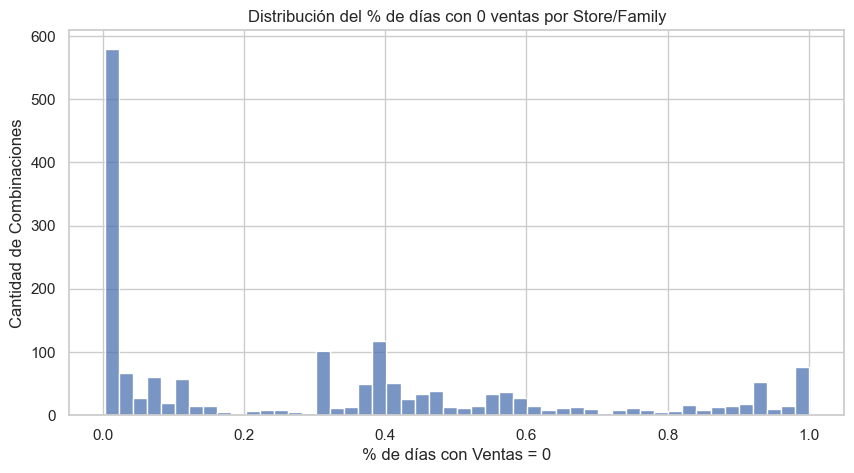

In [3]:
# Calculamos el porcentaje de días con ventas = 0 para cada combinación
total_days = train['date'].nunique()
zero_sales = train[train['sales'] == 0].groupby(['store_nbr', 'family']).size().reset_index(name='zero_days')
zero_sales['zero_pct'] = zero_sales['zero_days'] / total_days

dead_series = zero_sales[zero_sales['zero_pct'] >= 0.99]
highly_seasonal_or_new = zero_sales[(zero_sales['zero_pct'] >= 0.90) & (zero_sales['zero_pct'] < 0.99)]

print(f"Total de combinaciones store/family posibles: {train['store_nbr'].nunique() * train['family'].nunique()}")
print(f"Combinaciones 'muertas' (>99% de ceros): {len(dead_series)}")
print(f"Combinaciones altamente estacionales o introducidas recientemente (90-99% ceros): {len(highly_seasonal_or_new)}")

plt.figure(figsize=(10, 5))
sns.histplot(zero_sales['zero_pct'], bins=50)
plt.title('Distribución del % de días con 0 ventas por Store/Family')
plt.xlabel('% de días con Ventas = 0')
plt.ylabel('Cantidad de Combinaciones')
plt.show()

*R/* Hay un pico enorme en 1.0 (100% ceros). Muchas familias (como *BOOKS*, *BABY CARE*) simplemente no se venden en ciertas tiendas, comportándose como series "muertas".

## 2. ¿Qué familias concentran el 80% del volumen de ventas?

Familias que hacen el 80% de las ventas:


,family,sales,cumulative_pct
0,GROCERY I,3.434627e+08,0.319903
1,BEVERAGES,2.169545e+08,0.521976
2,PRODUCE,1.227047e+08,0.636264
3,CLEANING,9.752129e+07,0.727096
4,DAIRY,6.448771e+07,0.787161


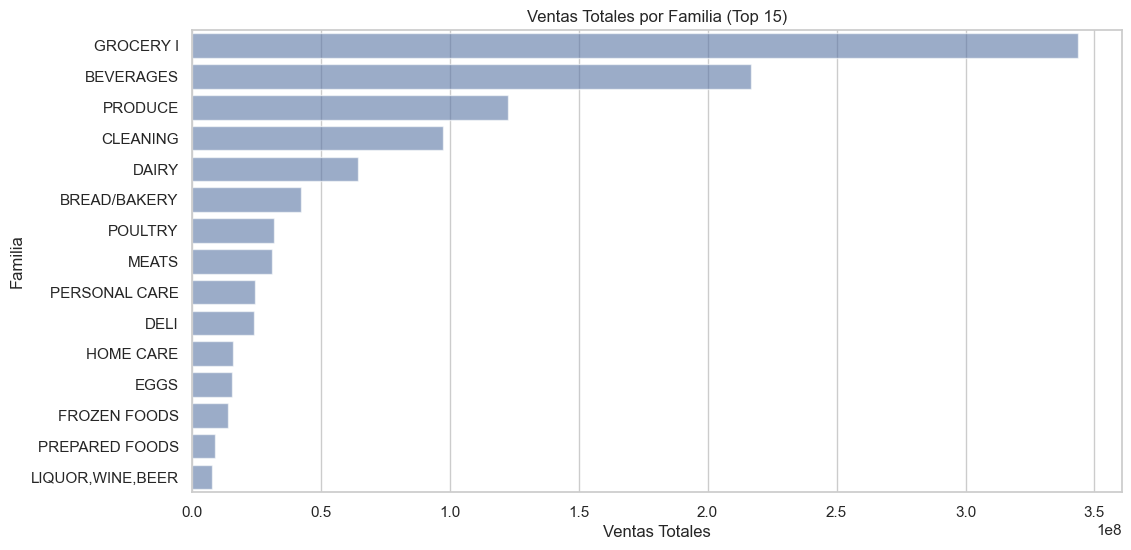

In [4]:
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False).reset_index()
family_sales['cumulative_pct'] = family_sales['sales'].cumsum() / family_sales['sales'].sum()

# Familias que representan el 80% de ventas
top_families = family_sales[family_sales['cumulative_pct'] <= 0.80]
print("Familias que hacen el 80% de las ventas:")
display(top_families)

plt.figure(figsize=(12, 6))
sns.barplot(data=family_sales.head(15), x='sales', y='family', color='b', alpha=0.6)
plt.title('Ventas Totales por Familia (Top 15)')
plt.xlabel('Ventas Totales')
plt.ylabel('Familia')
plt.show()

*R/* Solo un par de familias dominan masivamente el dataset (por ejemplo: `GROCERY I`, `BEVERAGES`, `PRODUCE`, `CLEANING`, `DAIRY`).

## 3. ¿Se ve claramente el spike del terremoto de abril 2016 en el agregado?

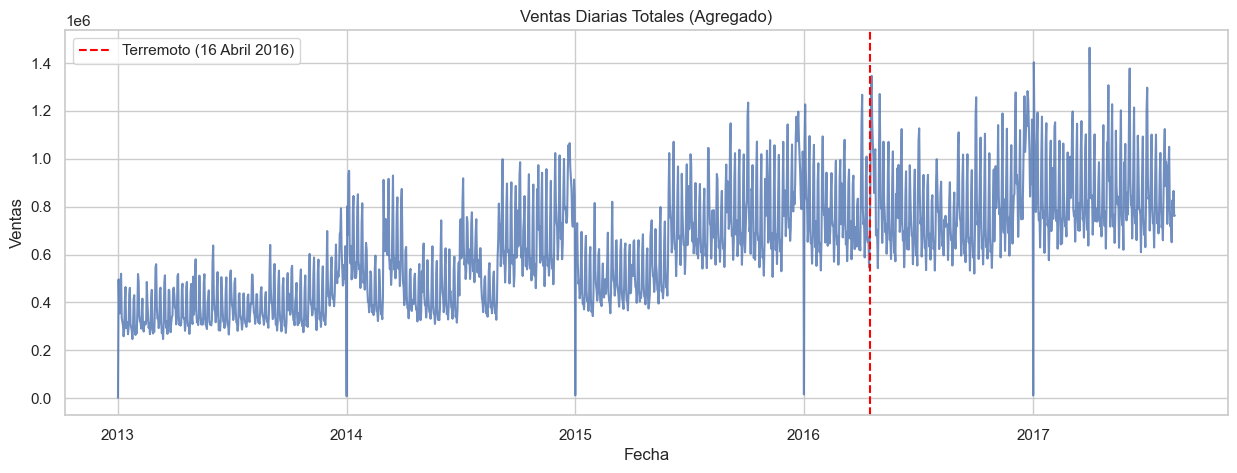

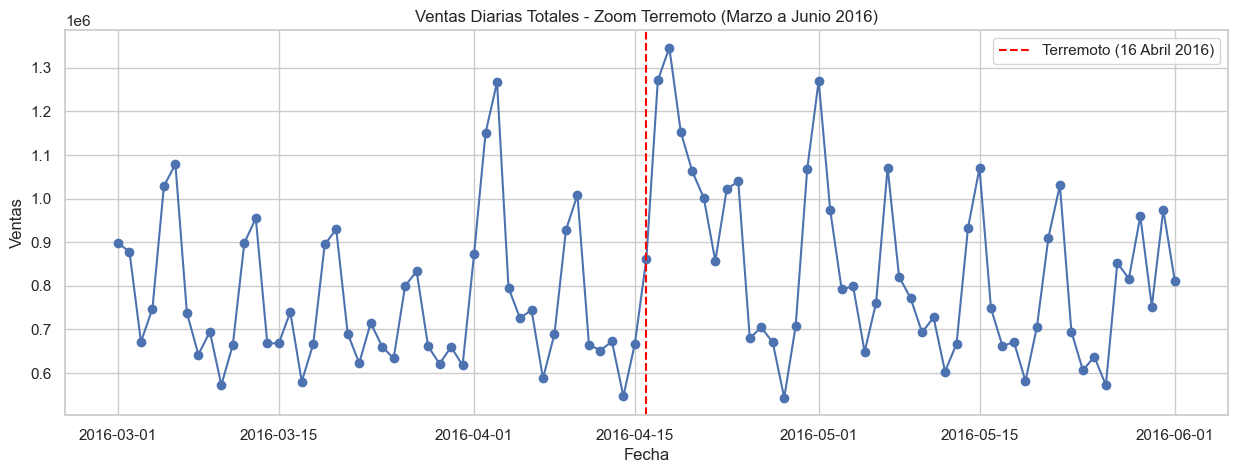

In [5]:
# Agregamos las ventas diarias totales
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], alpha=0.8)
plt.axvline(pd.to_datetime('2016-04-16'), color='red', linestyle='--', label='Terremoto (16 Abril 2016)')
plt.title('Ventas Diarias Totales (Agregado)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()

# Zoom a Abril-Mayo 2016
zoom_sales = daily_sales[(daily_sales['date'] >= '2016-03-01') & (daily_sales['date'] <= '2016-06-01')]
plt.figure(figsize=(15, 5))
plt.plot(zoom_sales['date'], zoom_sales['sales'], marker='o')
plt.axvline(pd.to_datetime('2016-04-16'), color='red', linestyle='--', label='Terremoto (16 Abril 2016)')
plt.title('Ventas Diarias Totales - Zoom Terremoto (Marzo a Junio 2016)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()

*R/* Sí, hay un gran repunte de ventas ('spike') inmediatamente después del 16 de abril de 2016, ya que la gente hizo compras de pánico/donación de víveres masivas.

## 4. ¿Qué tan fuerte es la estacionalidad semanal vs mensual vs anual?

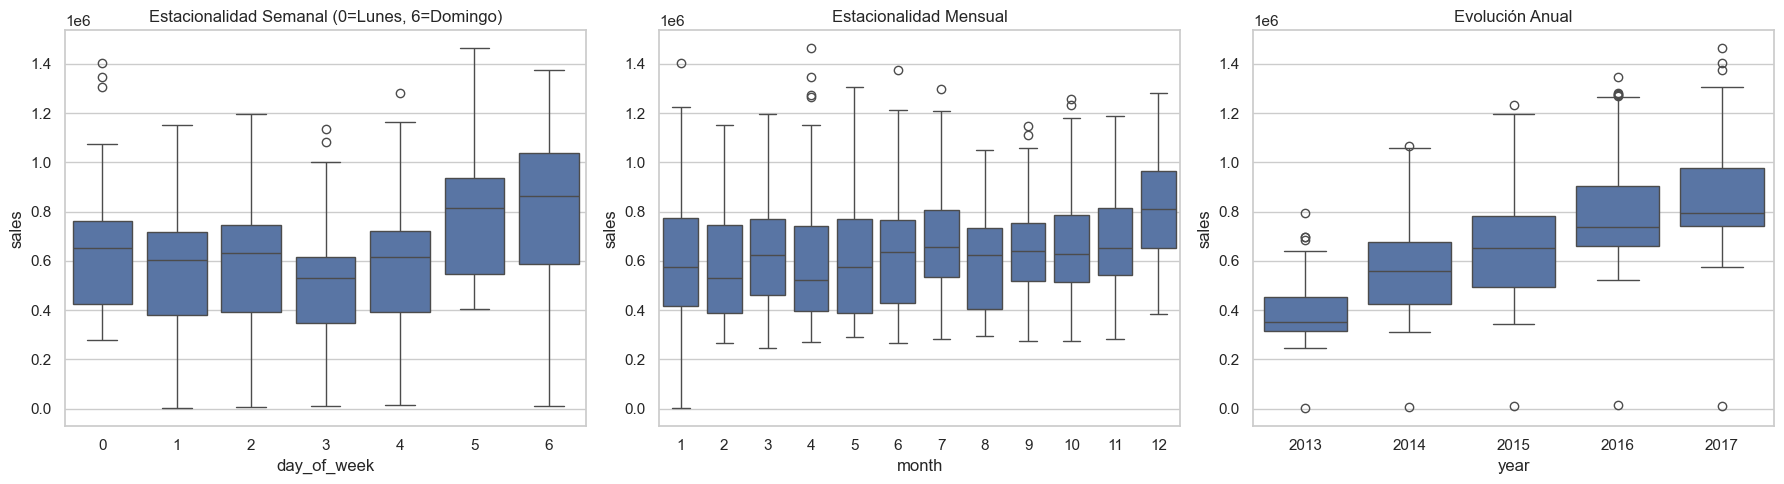

In [6]:
train['day_of_week'] = train['date'].dt.dayofweek
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Semanal
sns.boxplot(data=daily_sales.assign(day_of_week=daily_sales['date'].dt.dayofweek), x='day_of_week', y='sales', ax=axes[0])
axes[0].set_title('Estacionalidad Semanal (0=Lunes, 6=Domingo)')

# Mensual
sns.boxplot(data=daily_sales.assign(month=daily_sales['date'].dt.month), x='month', y='sales', ax=axes[1])
axes[1].set_title('Estacionalidad Mensual')

# Anual
sns.boxplot(data=daily_sales.assign(year=daily_sales['date'].dt.year), x='year', y='sales', ax=axes[2])
axes[2].set_title('Evolución Anual')

plt.tight_layout()
plt.show()

*R/*
- **Semanal:** Muy fuerte. Los fines de semana (sábado 5, domingo 6) las ventas son considerablemente más altas.
- **Mensual:** Hay un efecto marcado a fin de año (Diciembre, mes 12) que tiene el pico más alto. 
- **Anual:** Las ventas medias han ido subiendo ligeramente año tras año frente a 2013-2017.

## 5. ¿Cómo se correlaciona onpromotion con ventas por familia?

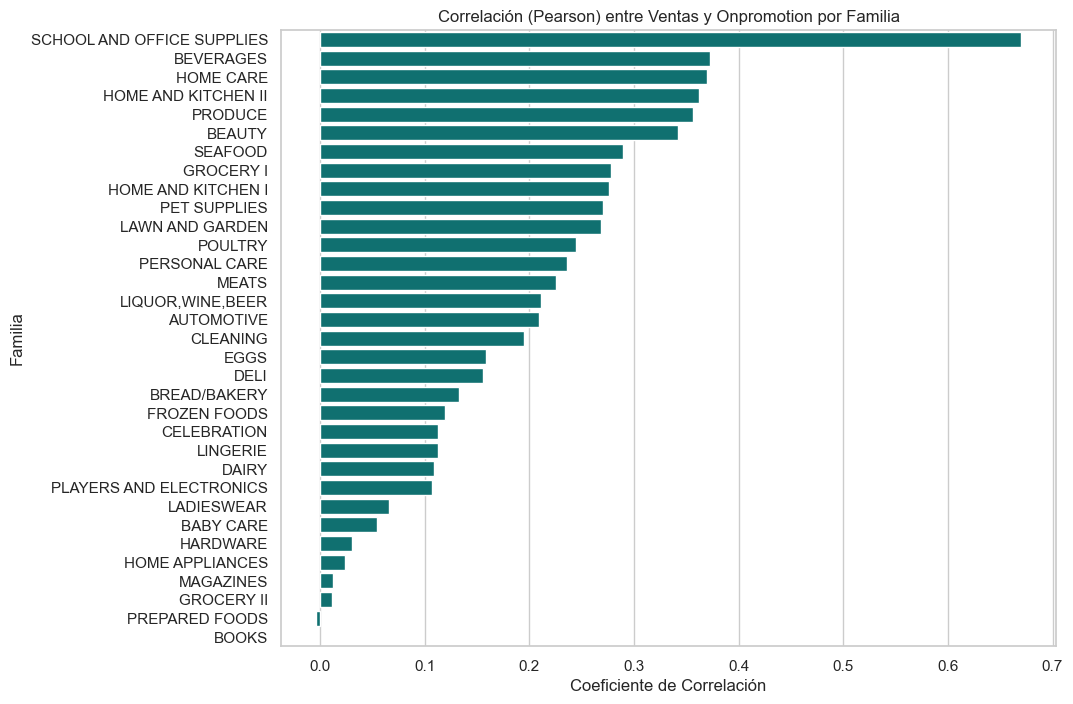

In [7]:
# Calculamos la correlación onpromotion vs sales agrupado por familia
prom_corr = train.groupby('family')[['sales', 'onpromotion']].corr().iloc[0::2, -1].reset_index()
prom_corr = prom_corr.rename(columns={'onpromotion': 'correlation'}).drop('level_1', axis=1)
prom_corr = prom_corr.sort_values('correlation', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=prom_corr, x='correlation', y='family', color='teal')
plt.title('Correlación (Pearson) entre Ventas y Onpromotion por Familia')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Familia')
plt.show()

*R/* Hay familias fuertemente afectadas por las promociones (como *GROCERY I*, *BEVERAGES*, *CLEANING*), que presentan alta correlación lineal. Sin embargo, en familias como *BOOKS* o algunas de ropa/accesorios la correlación es mínima o nula. Esto indica que la variable on_promotion será muy útil pero de impacto desigual según la familia.